# CRT matmul

Emulate any FP precision using only int8 arithmetic. From [Ozaki scheme II](https://arxiv.org/abs/2504.08009).

In [1]:
import os
import sys

if "COLAB_GPU" in os.environ:
    os.system("git clone https://github.com/PritRaj1/tensor_inv.git 2>/dev/null")
    sys.path.insert(0, "/content/tensor_inv/src")
else:
    src = "src" if os.path.isdir("src") else "../src"
    sys.path.insert(0, src)

In [2]:
import torch
import math
import time
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

## Floating point rounding

A 64-bit float stores: $(-1)^s \cdot 1.\text{mantissa} \cdot 2^{e - 1023}$

| segment | bits | role |
|---|---|---|
| sign | 1 | +/- |
| exponent | 11 | scale (powers of 2) |
| significand | 52 + 1 hidden = 53 | the digits |

53 bits of precision. Every arithmetic op rounds to nearest 53-bit result. In a dot product of length $k$, up to $k$ rounding errors accumulate.

In [3]:
import struct


def show_bits(label, x):
    """IEEE 754 bit layout."""
    raw = struct.unpack(">Q", struct.pack(">d", x))[0]
    sign = "+" if (raw >> 63) == 0 else "-"
    exp = (raw >> 52) & 0x7FF
    frac = f"{raw & ((1 << 52) - 1):052b}"
    grouped = " ".join(frac[i : i + 4] for i in range(0, 52, 4))
    print(f" {label} = {x}")
    print(f"   {sign} 1.{grouped} * 2^{exp - 1023}")


show_bits("1.0", 1.0)
show_bits("1.0 + eps", 1.0 + 2**-52)
show_bits("1.0 + eps/2", 1.0 + 2**-53)  # rounds back to 1.0
print(f"\n1.0 + eps/2 == 1.0? {1.0 + 2**-53 == 1.0}")
print("Below rounding threshold, vanishes")

 1.0 = 1.0
   + 1.0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 * 2^0
 1.0 + eps = 1.0000000000000002
   + 1.0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0001 * 2^0
 1.0 + eps/2 = 1.0
   + 1.0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 * 2^0

1.0 + eps/2 == 1.0? True
below rounding threshold, vanishes


Same thing happens in matmul. Each dot product accumulates $O(k)$ rounding errors.

On a theoretical hardware with only int8 (cheap silicon, tensor cores), there's no FP64 matmul at all. CRT gives FP64-accurate matmul using only int8 arithmetic.

In [4]:
from tensor_inv import crt_matmul

# CRT matmul matches FP64, using only int8 ops internally
torch.manual_seed(42)
A = torch.randn(64, 64, dtype=torch.float64)
B = torch.randn(64, 64, dtype=torch.float64)

C_torch = A @ B
C_crt = crt_matmul(A, B)

diff = (C_crt - C_torch).abs()
print(f"max abs difference: {diff.max().item():.2e}")
print(f"mean abs difference: {diff.mean().item():.2e}")
print("CRT matches FP64. All matmuls were int8 x int8 -> int32")

max abs difference: 1.78e-14
mean abs difference: 1.90e-15
CRT matches FP64. All matmuls were int8 x int8 -> int32


## Flow

| Step | Operation | Types |
|------|-----------|-------|
| 1 | Scale rows of $A$, cols of $B$ | float -> int64 |
| 2 | Reduce mod primes $p_i < 128$ | int64 -> int8 |
| 3 | Matmul per prime | int8 x int8 -> int32 |
| 4 | CRT reconstruction | int32 -> int64 -> float |
| 5 | Rescale | float |

Steps 2-4 are all integer ops. No rounding until final rescale (step 5).

Precision from input dtype. More mantissa bits = more primes.

## Chinese Remainder Theorem

Given coprime $m_1, \ldots, m_L$ and residues $r_i = x \bmod m_i$, CRT recovers $x$ uniquely if $|x| < \prod m_i / 2$.

Key constraint: product of primes must exceed twice max possible dot-product value. Larger $k$ or more mantissa bits = need more primes.

In [5]:
primes = [3, 5, 7, 11, 13]
M = math.prod(primes)
x = 12345
residues = [x % p for p in primes]

# reconstruct
x_rec = 0
for r, m in zip(residues, primes):
    Mi = M // m
    x_rec += r * Mi * pow(Mi, -1, m)
x_rec %= M

print(f"x = {x}, residues = {residues}")
print(f"recovered = {x_rec}, match: {x == x_rec}")
print(f"product of primes = {M}, covers |x| < {M // 2}")

x = 12345, residues = [0, 0, 4, 3, 8]
recovered = 12345, match: True
product of primes = 15015, covers |x| < 7507


## Scaling to integers

Scale rows of $A$, cols of $B$ by powers of 2. `ldexp(x, n)` = $x \cdot 2^n$, exact in FP (just shifts the exponent, no rounding).

Per-row scaling: find max exponent $\alpha_i$, scale by $2^{b - \alpha_i}$ where $b$ = precision bits of dtype. Values land in $[-2^b, 2^b]$, round to integer. Only error: this final rounding ($\leq 0.5$).

$C_{ij} = 2^{\alpha_i + \beta_j} \cdot \sum_k \hat{A}_{ik} \hat{B}_{kj} \cdot 2^{-2b}$

In [6]:
BITS = 53  # FP64 precision (1 hidden + 52 stored)

torch.manual_seed(42)
A = torch.randn(4, 3, dtype=torch.float64)
B = torch.randn(3, 5, dtype=torch.float64)

# power-of-2 diagonal scaling (exact)
row_exp = A.abs().amax(dim=1).clamp(min=1e-300).frexp()[1]
col_exp = B.abs().amax(dim=0).clamp(min=1e-300).frexp()[1]

A_int = torch.ldexp(A, BITS - row_exp.unsqueeze(1)).round().to(torch.int64)
B_int = torch.ldexp(B, BITS - col_exp.unsqueeze(0)).round().to(torch.int64)

print(f"A range: [{A.min():.2f}, {A.max():.2f}]")
print(f"A_int range: [{A_int.min()}, {A_int.max()}]")
print(f"fits in int53: {A_int.abs().max() <= 2**BITS}")

A range: [-1.12, 2.21]
A_int range: [-5056895559868609, 7290041615712889]
fits in int53: True


## Modular reduction

Reduce each int64 entry mod small primes ($< 128$, fits int8). Each dot product becomes a dot product of int8 values mod $p$.

In [7]:
# fmt: off
primes = [3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53,
          59, 61, 67, 71, 73, 79, 83, 89, 97, 101, 103, 107, 109, 113, 127]
# fmt: on

# how many primes needed?
k = A.shape[1]
target = 2 * k * (2 ** (2 * BITS))
prod = 1
for i, p in enumerate(primes):
    prod *= p
    if prod > target:
        n_mod = i + 1
        break

moduli = primes[:n_mod]
print(f"inner dim k={k}, need {n_mod} primes: {moduli}")
print(f"product covers: {math.prod(moduli):.2e} > {target:.2e}")

inner dim k=3, need 23 primes: [3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89]
product covers: 1.19e+34 > 4.87e+32


## Per-prime matmul + CRT

Matmul in each residue channel independently (int8 x int8 -> int32). Reconstruct exact int64 result via CRT.

In [8]:
# per-prime matmul
residues = []
for m in moduli:
    a_mod = (A_int % m).to(torch.int8)
    b_mod = (B_int % m).to(torch.int8)
    c = a_mod.int() @ b_mod.int()
    residues.append(c % m)


# CRT reconstruction
def crt_scalar(rs, mods):
    M = math.prod(mods)
    x = 0
    for r, m in zip(rs, mods):
        Mi = M // m
        x += r * Mi * pow(Mi, -1, m)

    x %= M
    if x > M // 2:
        x -= M
    return x


rows, cols = residues[0].shape
C_crt = torch.empty(rows, cols, dtype=torch.float64)
for i in range(rows):
    for j in range(cols):
        rs = [residues[p][i, j].item() for p in range(n_mod)]
        C_crt[i, j] = math.ldexp(
            float(crt_scalar(rs, moduli)),
            row_exp[i].item() + col_exp[j].item() - 2 * BITS,
        )

C_ref = A @ B
print(f"max abs error: {(C_crt - C_ref).abs().max():.2e}")

max abs error: 6.66e-16


## Accuracy

Always FP64 precision internally, regardless of input dtype.

In [9]:
from tensor_inv import crt_matmul

torch.manual_seed(42)
A64 = torch.randn(128, 128, dtype=torch.float64)
B64 = torch.randn(128, 128, dtype=torch.float64)
ref = A64 @ B64

for dtype, label in [(torch.float32, "fp32"), (torch.float64, "fp64")]:
    A, B = A64.to(dtype), B64.to(dtype)
    C = crt_matmul(A, B)
    ref_d = A.double() @ B.double()
    nz = ref_d.abs() > 1e-12
    rel_err = ((C - ref_d).abs()[nz] / ref_d.abs()[nz]).max().item()
    print(f"{label}: max rel error = {rel_err:.3e}")

fp32: max rel error = 2.048e-03
fp64: max rel error = 1.187e-11


## Primes vs inner dimension

More primes needed as $k$ grows. Dot product range is $\sim 2k \cdot (2^b)^2$.

In [10]:
from tensor_inv.crt_matmul import _PRECISION_BITS, _PRIMES, _n_moduli

ks = [16, 32, 64, 128, 256, 512, 1024]

for dtype, label in [(torch.float32, "fp32"), (torch.float64, "fp64")]:
    bits = _PRECISION_BITS[dtype]
    print(f"\n{label} ({bits}-bit precision):")
    print(f"{'k':>6} {'primes':>8} {'product (bits)':>16}")
    print("-" * 34)
    for k in ks:
        n = _n_moduli(k, bits)
        prod_bits = math.log2(math.prod(_PRIMES[:n]))
        print(f"{k:>6} {n:>8} {prod_bits:>16.1f}")


fp32 (24-bit precision):
     k   primes   product (bits)
----------------------------------
    16       14             58.1
    32       14             58.1
    64       14             58.1
   128       14             58.1
   256       14             58.1
   512       14             58.1
  1024       15             63.8

fp64 (53-bit precision):
     k   primes   product (bits)
----------------------------------
    16       23            113.2
    32       23            113.2
    64       23            113.2
   128       24            119.8
   256       24            119.8
   512       24            119.8
  1024       24            119.8


## Benchmark

CRT matmul vs `torch.matmul` (FP64). On GPU, per-prime matmuls use INT8 tensor cores via `torch._int_mm`.

GPU: NVIDIA GeForce GTX 1650


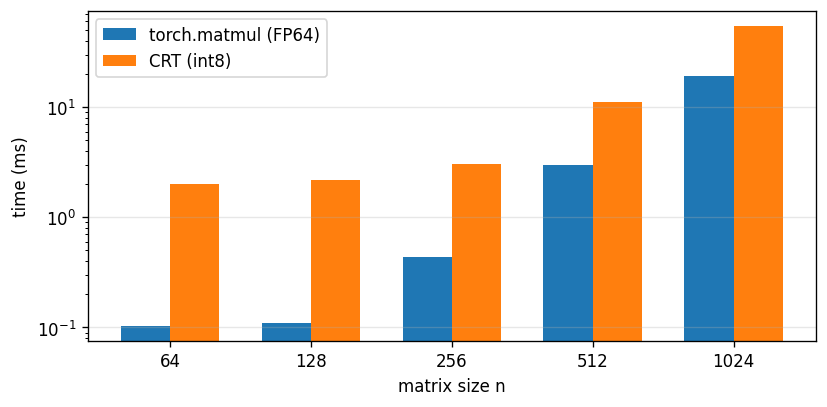

In [11]:
sizes = [64, 128, 256, 512, 1024, 2048, 4096]
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
if use_cuda:
    print(f"GPU: {torch.cuda.get_device_name()}")
else:
    print("no GPU, running on CPU")


def bench(fn, reps=10):
    for _ in range(3):
        fn()
    if use_cuda:
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(reps):
        fn()
    if use_cuda:
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / reps * 1000


t_ref, t_crt = [], []
for n in sizes:
    torch.manual_seed(0)
    A = torch.randn(n, n, dtype=torch.float64, device=device)
    B = torch.randn(n, n, dtype=torch.float64, device=device)
    t_ref.append(bench(lambda: A @ B))
    t_crt.append(bench(lambda: crt_matmul(A, B)))

x = range(len(sizes))
w = 0.35
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar([i - w / 2 for i in x], t_ref, w, label="torch.matmul (FP64)")
ax.bar([i + w / 2 for i in x], t_crt, w, label="CRT (int8)")
ax.set_xticks(list(x))
ax.set_xticklabels([str(n) for n in sizes])
ax.set_xlabel("matrix size n")
ax.set_ylabel("time (ms)")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()